# Pythia cosine summaries

Load the `checkpoint0` cosine summaries computed by `pythia/cosines.py` and plot only the full cosine distributions. The notebook shows one figure per layer, with three panels for the three representations: concatenated last 3 tokens, mean of the last 3 tokens, and last token only.

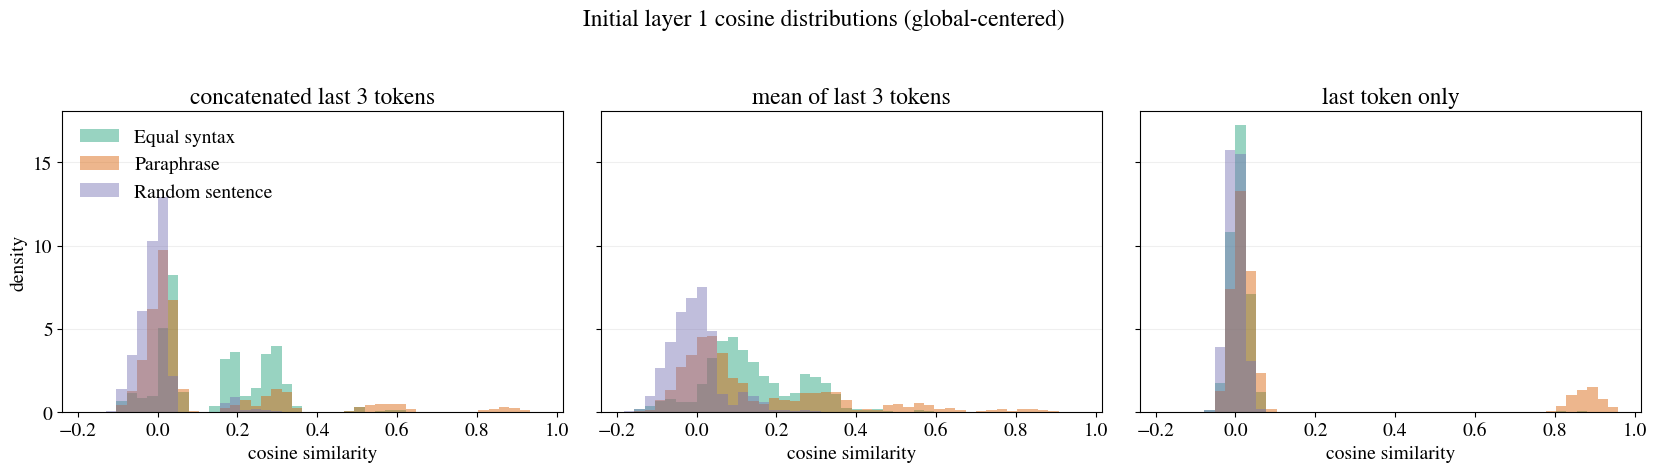

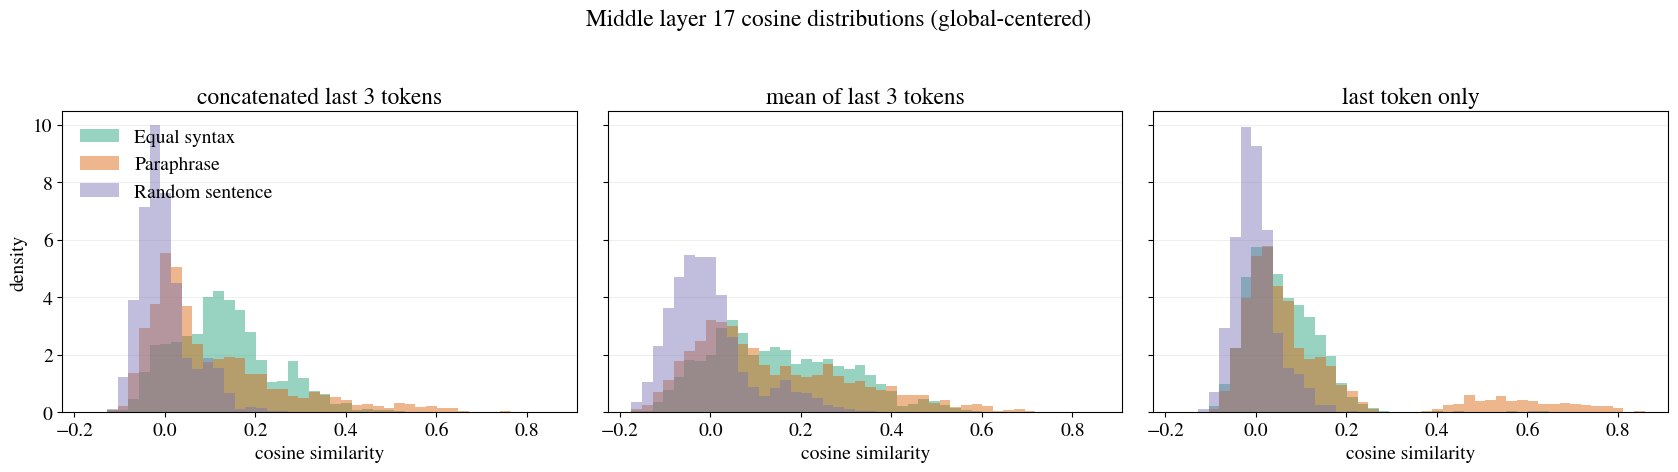

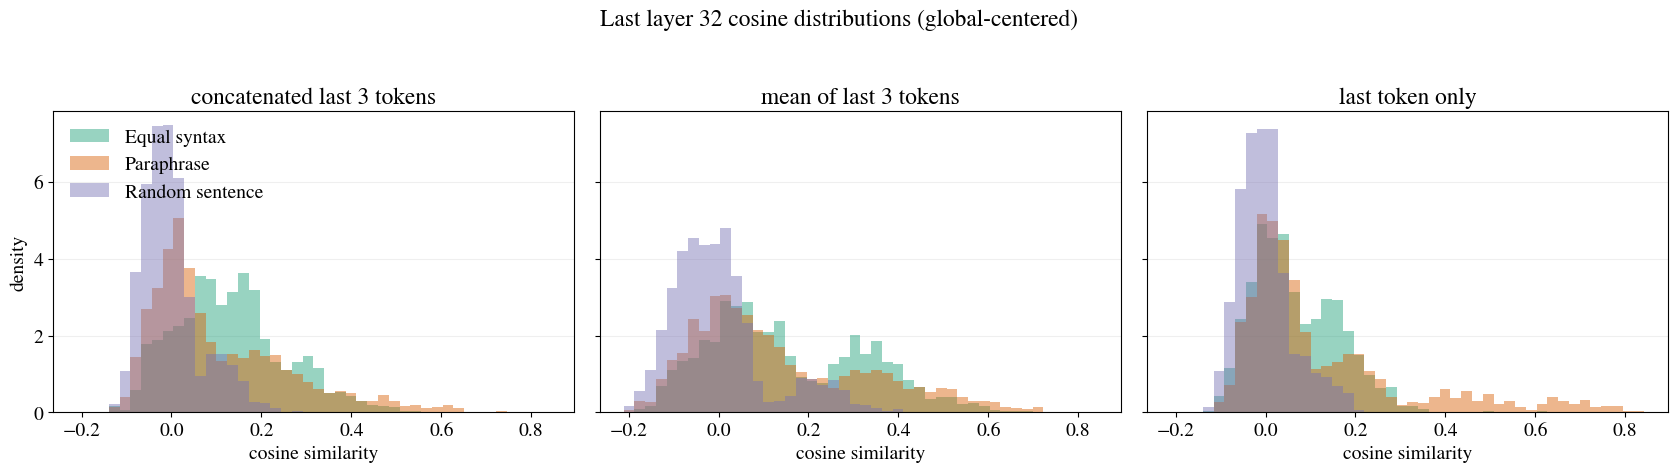

concatenated last 3 tokens
/home/acevedo/syn-sem/pythia/results/model_pythia6p9b_step0/cosines/avg_tokens_0/min_token_length_3/n_chunks_21/global_center_flag_1

mean of last 3 tokens
/home/acevedo/syn-sem/pythia/results/model_pythia6p9b_step0/cosines/avg_tokens_1/min_token_length_3/n_chunks_21/global_center_flag_1

last token only
/home/acevedo/syn-sem/pythia/results/model_pythia6p9b_step0/cosines/avg_tokens_0/min_token_length_3/n_chunks_21/global_center_flag_1/n_tokens_1



{'avg_tokens': 0,
 'candidate_layers': [1,
  3,
  5,
  7,
  9,
  11,
  13,
  15,
  17,
  19,
  21,
  23,
  25,
  27,
  29,
  32],
 'created_at': '2026-03-30T10:20:28',
 'global_center_flag': 1,
 'min_token_length': 3,
 'model': 'pythia6p9b_step0',
 'n_chunks': 21,
 'n_tokens': 1,
 'random_counts': [2018, 2018, 2018],
 'random_stds': [0.027016103267669678,
  0.052074648439884186,
  0.05971018597483635],
 'seed': 0,
 'selected_layers': [1, 17, 32],
 'semantic_counts': [2018, 2018, 2018],
 'semantic_dir_A': '/home/acevedo/syn-sem/datasets/activations/sem/second/pythia6p9b_step0/matching/english/0',
 'semantic_dir_B': '/home/acevedo/syn-sem/datasets/activations/sem/second/pythia6p9b_step0/matching/english/1',
 'semantic_stds': [0.3034215569496155,
  0.20268894731998444,
  0.19126734137535095],
 'syntax_counts': [2098, 2098, 2098],
 'syntax_dir_A': '/home/acevedo/syn-sem/datasets/activations/syn/second/pythia6p9b_step0/matching/english/0',
 'syntax_dir_B': '/home/acevedo/syn-sem/datasets/ac

In [5]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

model = 'pythia6p9b_step0'
min_token_length = 3
n_chunks = 21
global_center_flag = 1
layer_labels = ['Initial', 'Middle', 'Last']
series_meta = [
    ('Equal syntax', 'syntax_cosines', '#1b9e77'),
    ('Paraphrase', 'semantic_cosines', '#d95f02'),
    ('Random sentence', 'random_cosines', '#7570b3'),
]
run_configs = [
    {'avg_tokens': 0, 'n_tokens': 3, 'label': 'concatenated last 3 tokens'},
    {'avg_tokens': 1, 'n_tokens': 3, 'label': 'mean of last 3 tokens'},
    {'avg_tokens': 0, 'n_tokens': 1, 'label': 'last token only'},
]

def load_run(avg_tokens, n_tokens):
    root = (
        Path('/home/acevedo/syn-sem/pythia/results')
        / f'model_{model}'
        / 'cosines'
        / f'avg_tokens_{avg_tokens}'
        / f'min_token_length_{min_token_length}'
        / f'n_chunks_{n_chunks}'
        / f'global_center_flag_{global_center_flag}'
    )
    if avg_tokens == 0 and n_tokens != min_token_length:
        root = root / f'n_tokens_{n_tokens}'
    data = np.load(root / 'cosines.npz')
    metadata = json.loads((root / 'metadata.json').read_text())
    return root, data, metadata

rcpsize = 14
plt.rcParams['xtick.labelsize'] = rcpsize
plt.rcParams['ytick.labelsize'] = rcpsize
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['font.size'] = rcpsize

loaded_runs = []
for config in run_configs:
    root, data, metadata = load_run(config['avg_tokens'], config['n_tokens'])
    loaded_runs.append((config, root, data, metadata))

for layer_index, layer_label in enumerate(layer_labels):
    fig, axes = plt.subplots(1, 3, figsize=(17.0, 4.6), sharex=True, sharey=True)
    layer_id = int(loaded_runs[0][2]['layers'][layer_index])
    layer_min = min(float(data[dist_key][layer_index].min()) for _, _, data, _ in loaded_runs for _, dist_key, _ in series_meta)
    layer_max = max(float(data[dist_key][layer_index].max()) for _, _, data, _ in loaded_runs for _, dist_key, _ in series_meta)
    bins = np.linspace(layer_min, layer_max, 45)

    for ax, (config, root, data, metadata) in zip(axes, loaded_runs):
        for name, dist_key, color in series_meta:
            ax.hist(
                data[dist_key][layer_index],
                bins=bins,
                density=True,
                alpha=0.45,
                color=color,
                label=name,
            )
        ax.set_title(config['label'])
        ax.set_xlabel('cosine similarity')
        ax.grid(axis='y', alpha=0.2)
        ax.set_axisbelow(True)

    axes[0].set_ylabel('density')
    axes[0].legend(frameon=False, loc='upper left')
    fig.suptitle(f'{layer_label} layer {layer_id} cosine distributions (global-centered)', y=1.03)
    plt.tight_layout()
    plt.show()

for config, root, data, metadata in loaded_runs:
    print(config['label'])
    print(root)
    print()

loaded_runs[-1][3]